In [1]:
# ================================
# 📦 Step 1: Imports & Setup
# ================================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             accuracy_score, jaccard_score, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ⚙️ Config
IMAGE_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25

2026-04-18 16:03:30.701111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776528210.931470      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776528210.998398      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Dataset paths
train_image_path = "/kaggle/input/landslide-divided/dataset/train/images"
train_mask_path = "/kaggle/input/landslide-divided/dataset/train/masks"
val_image_path = "/kaggle/input/landslide-divided/dataset/validation/images"
val_mask_path = "/kaggle/input/landslide-divided/dataset/validation/masks"
test_image_path = "/kaggle/input/landslide-divided/dataset/test/images"
test_mask_path = "/kaggle/input/landslide-divided/dataset/test/masks"



In [3]:
# ================================
# 📦 Step 2: Preprocessing Functions
# ================================
def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (IMAGE_SIZE, IMAGE_SIZE))
    x = x / 255.0
    return x

def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    x = cv2.resize(x, (IMAGE_SIZE, IMAGE_SIZE))
    x = x / 255.0
    x = np.expand_dims(x, axis=-1)
    return x

class DataGen(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_images = self.image_paths[idx * self.batch_size: (idx + 1) * self.batch_size]
        batch_masks = self.mask_paths[idx * self.batch_size: (idx + 1) * self.batch_size]

        images = [read_image(img) for img in batch_images]
        masks = [read_mask(msk) for msk in batch_masks]

        return np.array(images), np.array(masks)

# File paths
train_images = sorted(glob(os.path.join(train_image_path, "*")))
train_masks = sorted(glob(os.path.join(train_mask_path, "*")))
val_images = sorted(glob(os.path.join(val_image_path, "*")))
val_masks = sorted(glob(os.path.join(val_mask_path, "*")))
test_images = sorted(glob(os.path.join(test_image_path, "*")))
test_masks = sorted(glob(os.path.join(test_mask_path, "*")))

# Generators
train_gen = DataGen(train_images, train_masks, BATCH_SIZE)
val_gen = DataGen(val_images, val_masks, BATCH_SIZE)


In [4]:
# Step 3: U-Net Model
def unet_model(input_size=(IMAGE_SIZE, IMAGE_SIZE, 3)):
    inputs = Input(input_size)
    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = MaxPooling2D()(c4)
    # Bottleneck
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(c5)
    # Decoder
    u6 = Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(512, 3, activation='relu', padding='same')(c6)
    u7 = Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(256, 3, activation='relu', padding='same')(c7)
    u8 = Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = Conv2D(128, 3, activation='relu', padding='same')(c8)
    u9 = Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = Conv2D(64, 3, activation='relu', padding='same')(c9)
    outputs = Conv2D(1, 1, activation='sigmoid')(c9)
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

model = unet_model()
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


I0000 00:00:1776528291.011479      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776528291.014211      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ================================
# 📦 Step 4: Training
# ================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)
I0000 00:00:1776528309.119216     105 service.cc:148] XLA service 0x799280002600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776528309.120207     105 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776528309.120228     105 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776528310.095718     105 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-04-18 16:05:14.514487: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng12{k11=0} for conv (f32[8,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x

173/173 ━━━━━━━━━━━━━━━━━━━━ 164s 645ms/step - accuracy: 0.9459 - loss: 0.2106 - val_accuracy: 0.9527 - val_loss: 0.1144
Epoch 2/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 492ms/step - accuracy: 0.9464 - loss: 0.1054 - val_accuracy: 0.9505 - val_loss: 0.0986
Epoch 3/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 493ms/step - accuracy: 0.9441 - loss: 0.1073 - val_accuracy: 0.9465 - val_loss: 0.0980
Epoch 4/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 492ms/step - accuracy: 0.9435 - loss: 0.1085 - val_accuracy: 0.9535 - val_loss: 0.0969
Epoch 5/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 493ms/step - accuracy: 0.9517 - loss: 0.0963 - val_accuracy: 0.9519 - val_loss: 0.0941
Epoch 6/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 488ms/step - accuracy: 0.9454 - loss: 0.1101 - val_accuracy: 0.9542 - val_loss: 0.0903
Epoch 7/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 491ms/step - accuracy: 0.9500 - loss: 0.0952 - val_accuracy: 0.9536 - val_loss: 0.0894
Epoch 8/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 85s 488ms/step - accuracy: 0.9498 - loss: 0.0962 - va

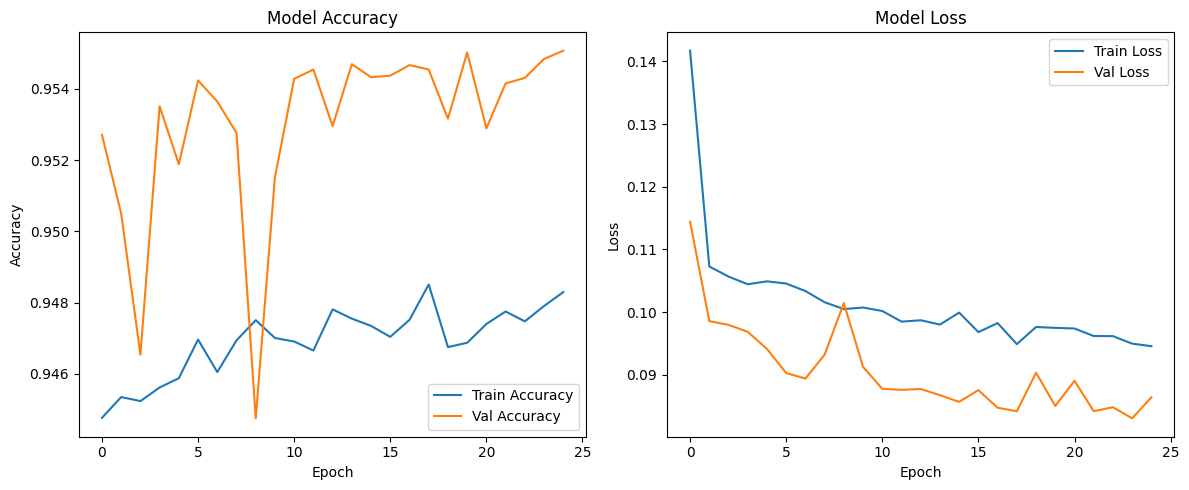

In [6]:
# ================================
# 📊 Step 5: Training Curves
# ================================
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [7]:
# ================================
# 📊 Step 6: Evaluation on Test Set
# ================================
test_gen = DataGen(test_images, test_masks, BATCH_SIZE)
loss, acc = model.evaluate(test_gen)
print(f"\n🧪 Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

final_train_acc = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]
print(f"📈 Final Training Accuracy: {final_train_acc:.4f}, Training Loss: {final_train_loss:.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9454 - loss: 0.1063

🧪 Test Loss: 0.1033, Test Accuracy: 0.9475
📈 Final Training Accuracy: 0.9483, Training Loss: 0.0946


In [8]:
# ================================
# 📊 Step 7: Metrics & Confusion Matrix
# ================================
def dice_coef(y_true, y_pred):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection) / (np.sum(y_true_f) + np.sum(y_pred_f) + 1e-7)

# Collect predictions & ground truth
y_true_all, y_pred_all = [], []
for i in range(len(test_images)):
    image = read_image(test_images[i])
    mask = read_mask(test_masks[i])
    pred = model.predict(np.expand_dims(image, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    y_true_all.extend(mask.flatten())
    y_pred_all.extend(pred.flatten())

y_true_all = np.array(y_true_all, dtype=np.uint8)
y_pred_all = np.array(y_pred_all, dtype=np.uint8)

# Metrics
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
accuracy = accuracy_score(y_true_all, y_pred_all)
precision = precision_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)
iou = jaccard_score(y_true_all, y_pred_all)
dice = dice_coef(y_true_all, y_pred_all)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━


📊 Classification Report:
              precision    recall  f1-score   support

No Landslide       0.97      0.99      0.98  12584239
   Landslide       0.63      0.29      0.40    457425

    accuracy                           0.97  13041664
   macro avg       0.80      0.64      0.69  13041664
weighted avg       0.96      0.97      0.96  13041664


📈 Pixel-wise Evaluation Metrics:
Accuracy: 0.9692
Precision: 0.6307
Recall: 0.2939
F1 Score: 0.4010
IoU Score: 0.2508
Dice Coefficient: 0.4010


<Figure size 500x500 with 0 Axes>

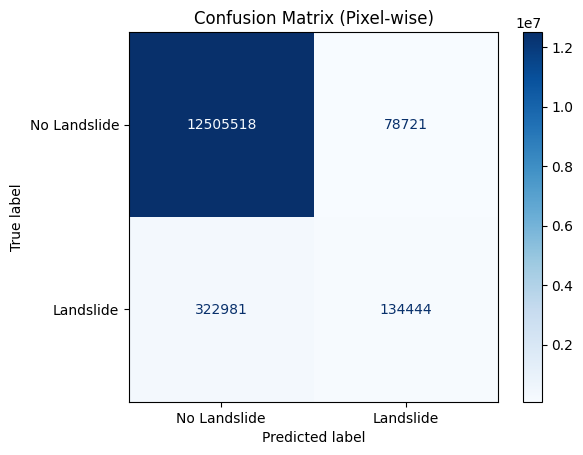

In [9]:
# Classification Report
target_names = ['No Landslide', 'Landslide']
print("\n📊 Classification Report:")
print(classification_report(y_true_all, y_pred_all, target_names=target_names, digits=2))

# Additional Metrics
print("\n📈 Pixel-wise Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"IoU Score: {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=target_names)
plt.figure(figsize=(5, 5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (Pixel-wise)")
plt.show()

In [10]:
def calculate_area(mask):
    return np.sum(mask == 1)

def classify_severity(area):
    if area < 5000:
        return "Low"
    elif area < 20000:
        return "Medium"
    else:
        return "High"

def generate_heatmap(image, mask):
    heatmap = np.zeros_like(image)
    heatmap[:, :, 0] = mask.squeeze() * 255

    overlay = cv2.addWeighted(image.astype(np.float32), 0.7,
                              heatmap.astype(np.float32), 0.3, 0)
    return overlay

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


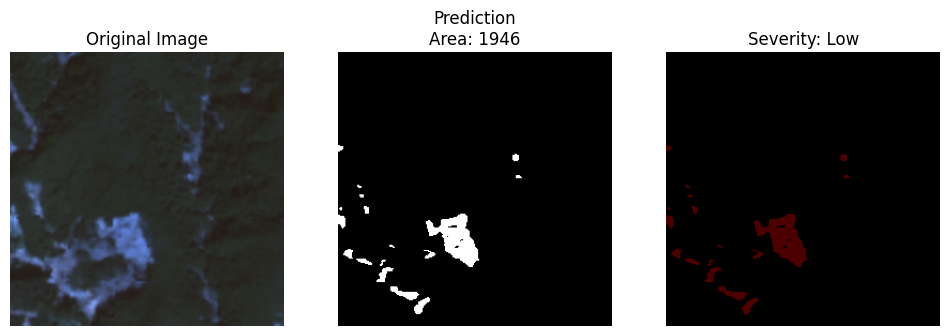

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


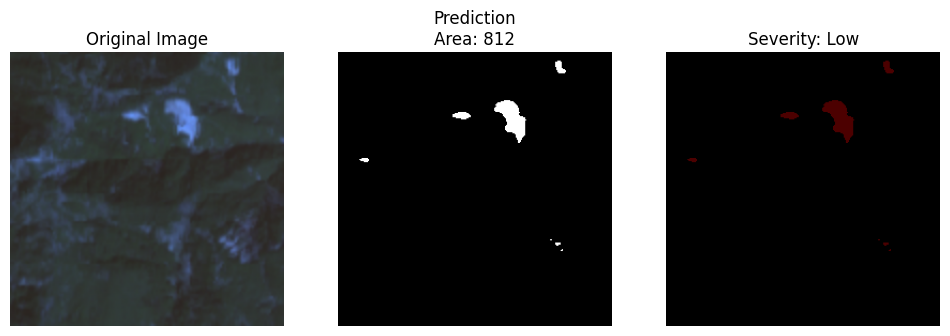

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


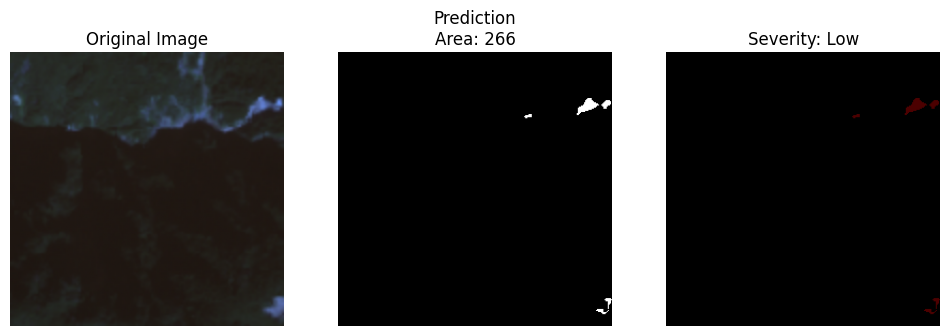

In [11]:
# ================================
# 🔍 Apply on Test Data
# ================================
for i in range(3):   # show 3 samples
    img = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(img, axis=0))[0]
    pred = (pred > 0.5).astype(np.uint8)

    # Area
    area = calculate_area(pred)

    # Severity
    severity = classify_severity(area)

    # Heatmap
    heatmap = generate_heatmap(img, pred)

    # -------------------------------
    # Display
    # -------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Prediction\nArea: {area}")
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Severity: {severity}")
    plt.imshow(heatmap.astype(np.uint8))
    plt.axis("off")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


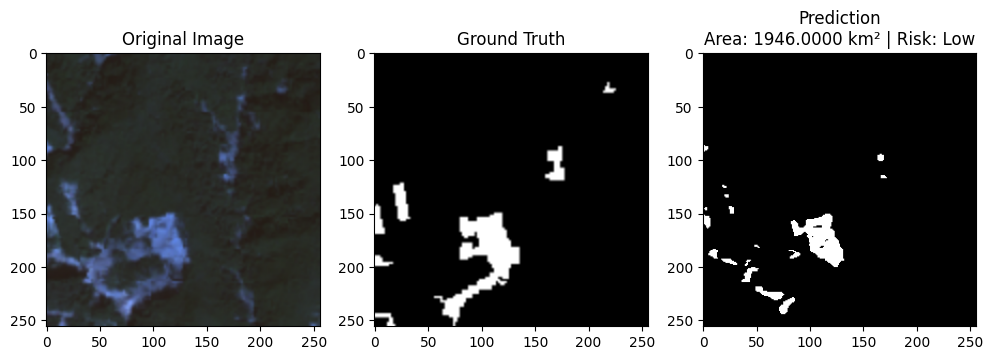

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


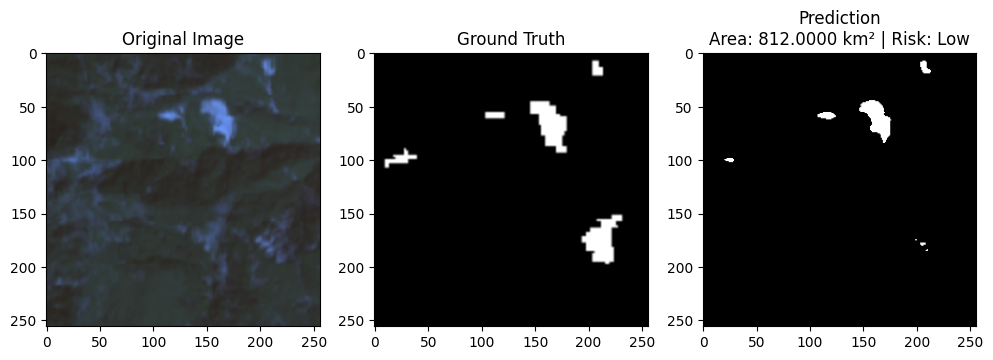

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


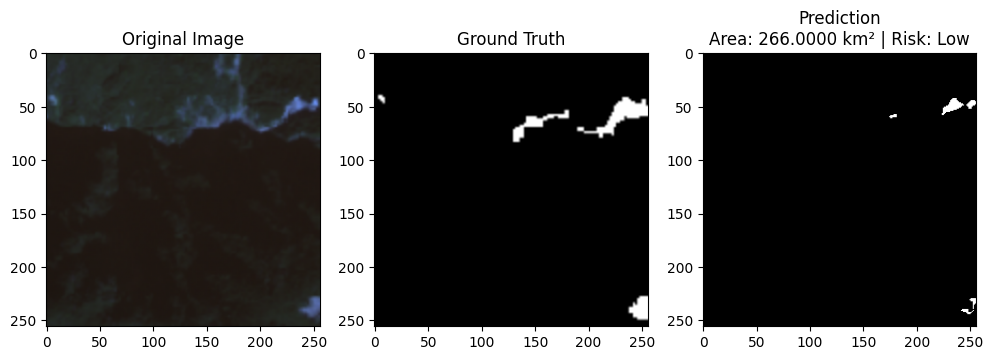

In [15]:
# ================================
# 📊 Step 9: Area Estimation & Risk Classification
# ================================

def calculate_area_and_risk(pred_mask, pixel_resolution=10):
    """
    pred_mask: binary landslide mask (0/1)
    pixel_resolution: meters per pixel (Sentinel-2 = 10m)
    """
    # Count landslide pixels
    landslide_pixels = np.sum(pred_mask)

    # Convert pixels → area (in sq. km)
    area = np.sum(pred_mask)  # m² → km²

    # Risk classification
    if area < 5000:
        risk = "Low"
    elif area < 20000:
        risk = "Medium"
    else:
        risk = "High"

    return area, risk

# Example on test images
for i in range(3):
    image = read_image(test_images[i])
    mask = read_mask(test_masks[i])

    pred = model.predict(np.expand_dims(image, axis=0))[0]
    pred_bin = (pred > 0.5).astype(np.uint8)[:, :, 0]

    # Estimate area & risk
    area, risk = calculate_area_and_risk(pred_bin)

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(image)

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(mask[:, :, 0], cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title(f"Prediction\nArea: {area:.4f} km² | Risk: {risk}")
    plt.imshow(pred_bin, cmap='gray')
    plt.show()
